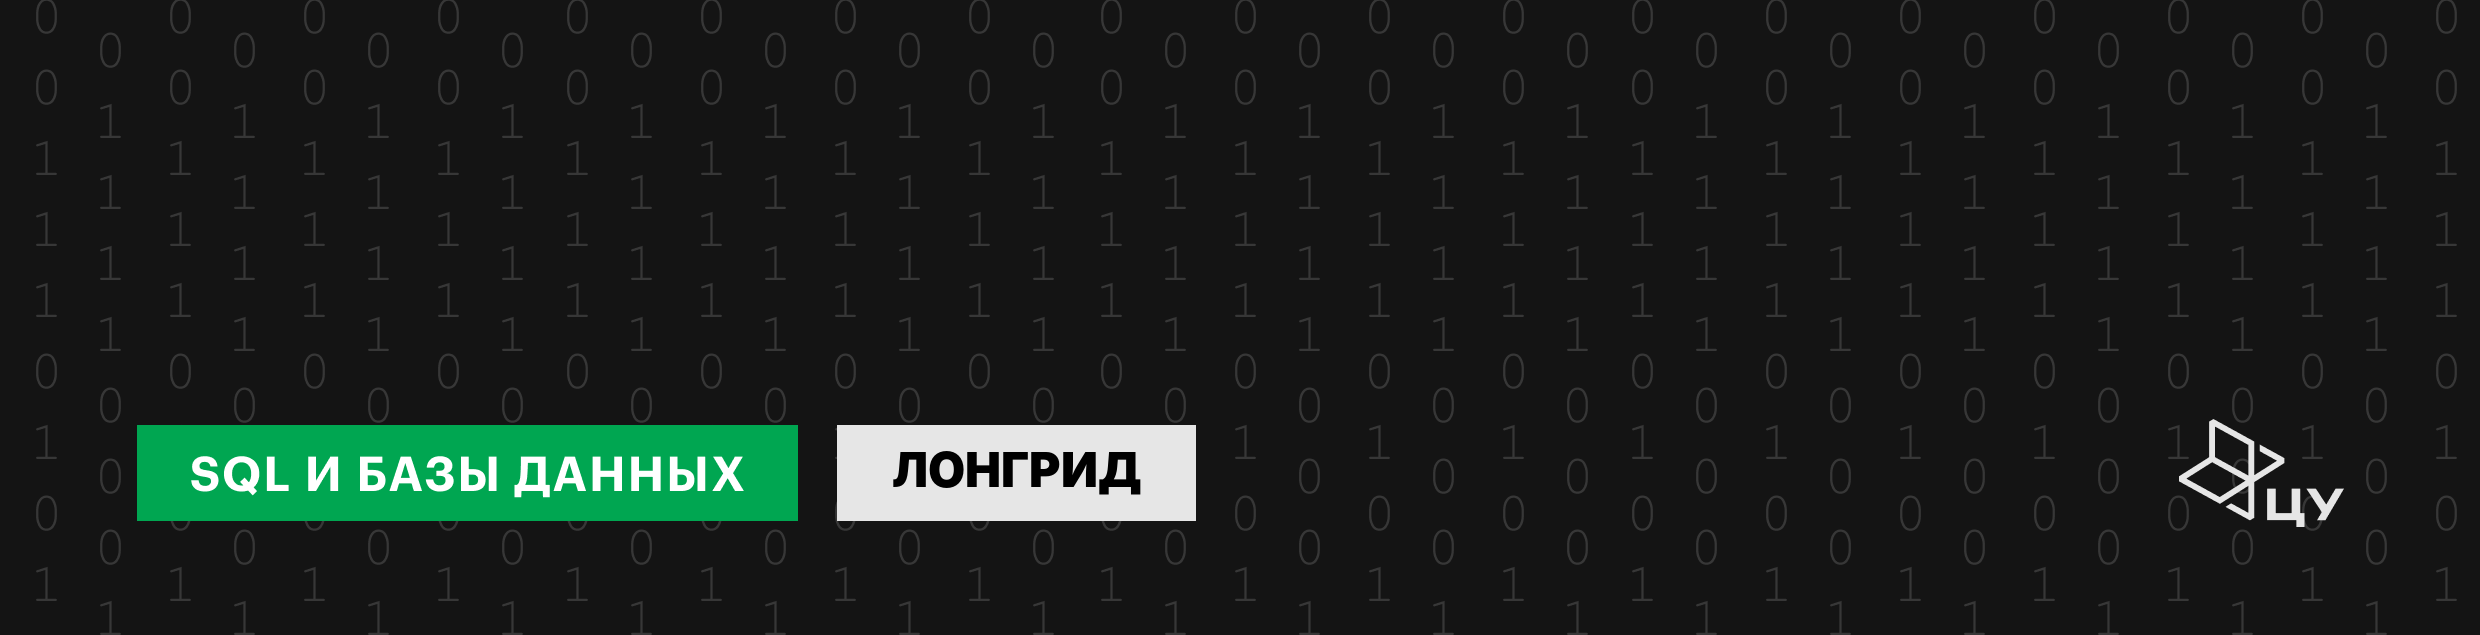

# Лонгрид по теме Введение в базы данных и SQL

В лонгриде есть задачи по ходу текста и в конце на понимание.

В этом материале разбираются базовые понятия SQL и баз данных: данные, базы данных, СУБД, виды СУБД, модели данных, реляционная модель и основные типы данных PostgreSQL.


Логин и пароль для подключения к базам данных PostgreSQL можно получить в сервисе самообслуживания (https://self-service.culab.ru).
 При получении нового пароля старый пароль будет аннулирован.

У каждого студента есть своя схема в наших базах данных. Называется так же, как логин, используемый при подключении.

Схема с общими таблицами называется databases_and_sql. При выполнении запросов в данном ноутбуке эта схема используется по умолчанию.

Описание таблиц и схему БД можно посмотреть тут:

https://centraluniversity.yonote.ru/share/0188ee4d-d0bb-4654-9d49-87dab28e9550/doc/tablicy-ispolzuemye-v-kurse-sql-i-bazy-dannyh-kXDYWB70FN

In [ ]:
import os,requests,time;url = "http://sql-exercise.sql-exercise-prod.svc.cluster.local/"
if os.path.exists("py_workshop.py"):
    os.remove("py_workshop.py")
if not os.path.exists("py_workshop.py"):
    response = requests.get(f"{url}get_py_workshop");
    if response.status_code == 200: 
        with open("py_workshop.py", "wb") as f: f.write(response.content);time.sleep(1)
# Проверь, что config.yaml (надо заполнить по инструкции) и py_workshop.py (скачается автоматически) находятся в папке с этим ноутбуком
from py_workshop import *;runner.set_url(url);runner.logon();schema_name = runner.user_schema
runner.course = 'sql'
runner.material( 'sqldb_an26_intro_longread', course_launch='dbsql_an_onl_26_fall')

1. Немного истории
2. Базы данных
3. СУБД: назначение и устройство
   - Для чего нужны СУБД
   - Из чего состоит СУБД
4. Виды СУБД
   - OLTP и OLAP
   - Модели данных
5. Типы данных в PostgreSQL
   - Числовые типы
   - Строки, даты, время и логические значения
6. Полезные ссылки и источники

![](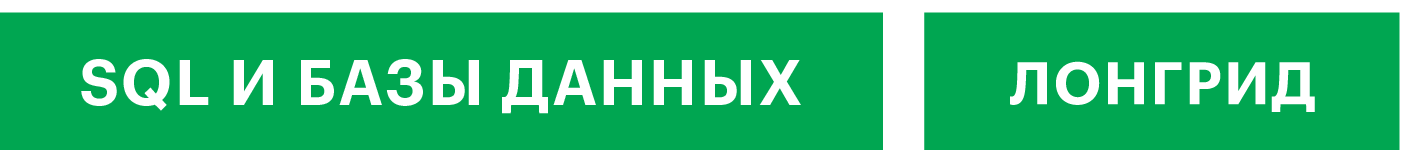 "image-left-layout|||aspect=0.5611385384044586")


## Немного истории

Системы хранения данных (СХД) прошли впечатляющий путь развития. За последние 60–70 лет они эволюционировали от простейших механических устройств до современных высокотехнологичных накопителей. Сегодняшние СХД — это не только результат стремительного научно-технического прогресса, но и свидетельство того, как инновации меняют наш мир.



 ![Ткацкий станок Бэзила Бушона, 19 век](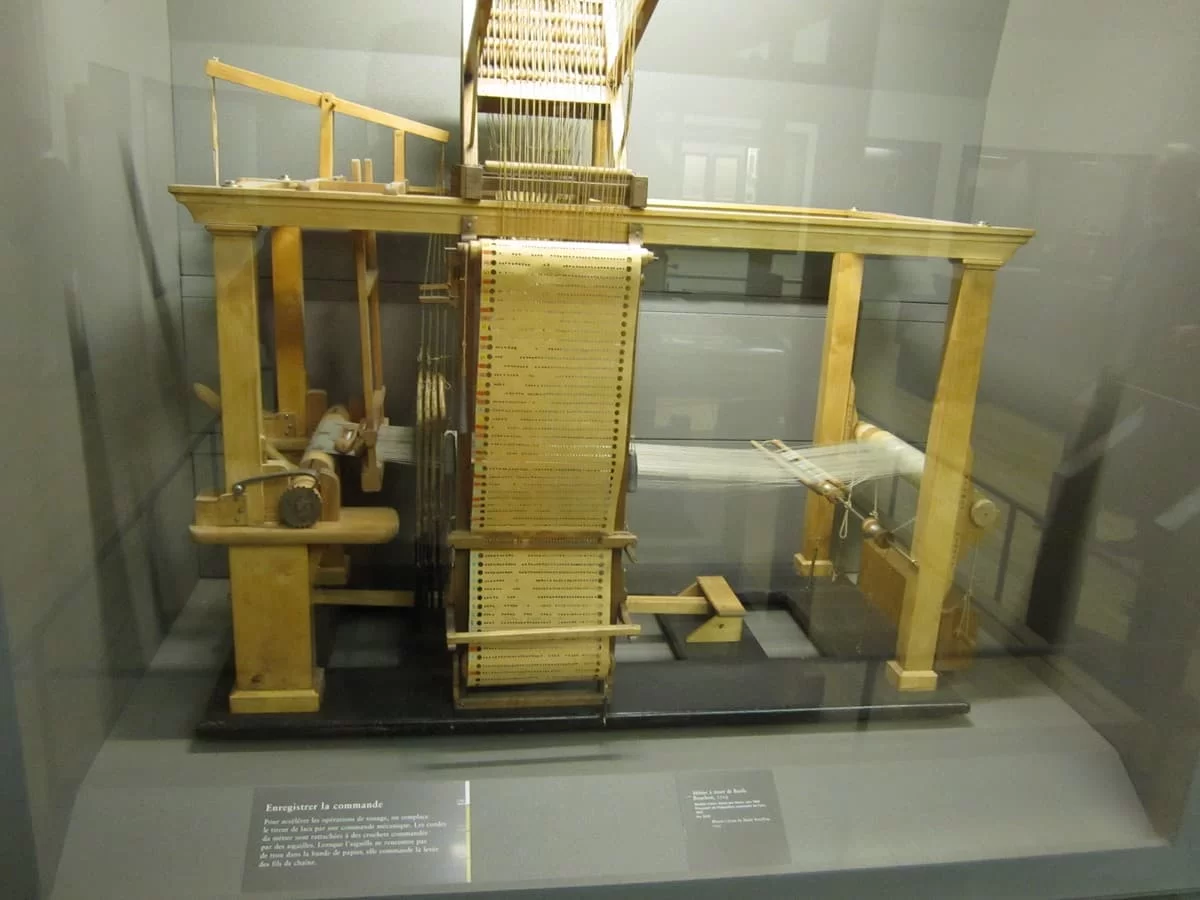 "aspect=0.9972844412401746")



История СХД началась задолго до появления первых компьютеров. В начале XIX века, в эпоху текстильной промышленности, французский ткач Базиль Бушон изобрёл перфорированную ленту. Этот носитель служил для управления ткацким станком, записывая «программы» в виде отверстий. Простая, но гениальная идея позволила автоматизировать создание узоров на тканях. Работник прижимал ленту к полотну игл, и лишь те нити, которые совпадали с перфорацией, проходили сквозь станок, формируя узор. Это изобретение стало первым шагом на пути к современным методам хранения и обработки данных.

С тех пор прошло почти три столетия, и технологии хранения данных изменились до неузнаваемости. XX век подарил миру множество разнообразных устройств: магнитные ленты, барабаны, жёсткие диски, гибкие диски, оптические диски и твердотельные накопители. Некоторые из них остались в прошлом, а другие, такие как накопители на основе твердотельной электроники, облачные хранилища и даже квантовые системы, продолжают развиваться, формируя будущее отрасли.

Современные СХД поражают своей ёмкостью, компактностью и скоростью. Объёмы данных, которые раньше занимали целые залы серверов, сегодня могут храниться на устройстве, помещающемся на ладони. Скорость передачи информации преодолела все мыслимые пределы, а расстояния больше не являются преградой. Человечество шагнуло в эпоху, где информация стала глобальным ресурсом, доступным каждому, и её роль в жизни общества трудно переоценить.

Подробнее прочесть об эволюции систем хранения данных можно [тут](https://storage.tadviser.ru/).

### Задача 1. Выведи факт об историческом носителе данных
Эта маленькая задача нужна, чтобы привыкнуть к идее: `SELECT` может вернуть данные даже без таблицы. Пока мы просто выводим два значения как одну строку результата.

Скопируй и выполни запрос:

```sql
SELECT 'перфокарта' AS storage_medium, 1804 AS approximate_year;
```

Здесь строка `'перфокарта'` и число `1804` становятся значениями двух столбцов.



In [ ]:
%%sql_query cell_1_1
-- Задача 1. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_1_2
--Проверка запроса для задачи 1. Отправь решение на проверку


## Базы данных

Базы данных везде вокруг нас. Любой сервис или приложение, которое ты используешь, хранит данные в своих базах данных: социальные сети хранят данные твоего профиля, историю сообщений, помнят, какие реакции и на какие сообщения ты поставил. И это нужно для корректной работы самого сервиса или приложения.

> **Данные** — это набор фактов, которые нужно хранить. Например, в магазине это может быть информация о товарах, клиентах и продажах.

Часто, когда мы говорим о базах данных, мы имеем в виду системы управления базами данных. Давай разбираться.

> **База данных (БД)** — это организованный набор информации, хранящейся в электронном виде. 

Фактически база данных представляет собой просто файл на диске компьютера, который умеет только хранить данные. И чтобы облегчить работу с БД, были придуманы системы управления базами данных (СУБД).

> **Система управления базами данных (СУБД)** — программное обеспечение, которое позволяет пользователю взаимодействовать с базой данных и даёт возможность, например, добавлять новые элементы, удалять старые, фильтровать и находить нужные элементы, менять их структуру, создавать резервные копии.

СУБД является связующим звеном между базой данных и пользовательскими запросами к ней.



### Задача 2. Раздели роль БД и СУБД в SELECT
Сейчас мы закрепляем различие между базой данных и СУБД. Запрос не обращается к таблицам: он просто формирует строку с четырьмя столбцами.

Вставь код в ячейку:

```sql
SELECT 'БД' AS database_object,
       'хранит данные' AS database_role,
       'СУБД' AS dbms_object,
       'управляет доступом' AS dbms_role;
```

Обрати внимание на `AS`: так мы задаём понятные имена столбцам.



In [ ]:
%%sql_query cell_2_1
-- Задача 2. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_2_2
--Проверка запроса для задачи 2. Отправь решение на проверку


 ![](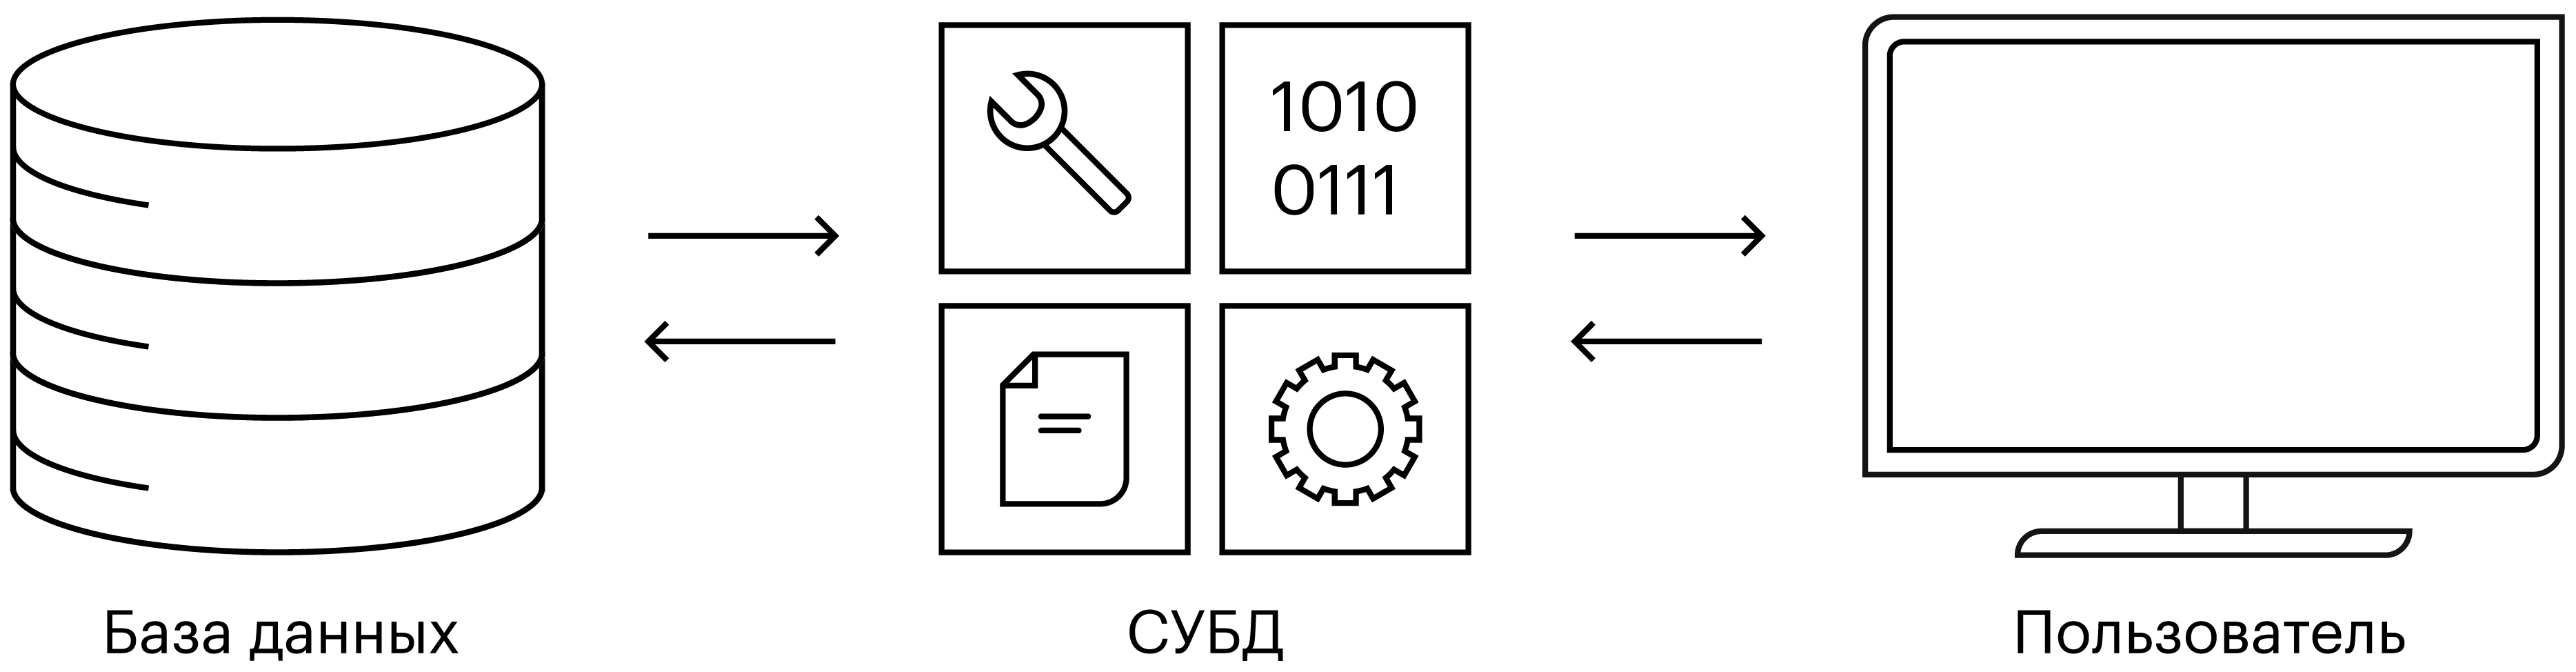 "aspect=1")





Если объяснять работу СУБД на примере онлайн-магазина, то получится следующая последовательность действий:

1. Пользователь открывает страницу со списком своих заказов и нажимает на кнопку «Посмотреть детали» для конкретного заказа.
2. Веб-приложение (сайт) отправляет запрос на сервер с идентификатором заказа (например: ID_Заказа = 12345).
3. Сервер преобразует запрос пользователя в SQL-запрос к базе данных.
4. На этом этапе подключается (образно выражаясь) СУБД. СУБД принимает запрос и выполняет его, используя базу данных:
   - ищет информацию о заказе в таблице «Заказы»;
   - находит клиента в таблице «Клиенты» по *ID_Клиента*;
   - находит товары, связанные с заказом, в таблице «Товары_В_Заказе» и их описание — в таблице «Товары».
5. СУБД возвращает данные в виде таблицы.
6. Сервер преобразует результаты в JSON или другой формат, удобный для передачи веб-приложению.
7. На стороне клиента веб-приложение обрабатывает данные и показывает их пользователю в удобной форме.

### Задача 3. Собери строку про запрос к заказу
В примере с интернет-магазином пользователь просит детали заказа. Сымитируем такую строку результата без обращения к реальной таблице заказов.

Используй запрос:

```sql
SELECT 12345 AS order_id,
       'details_requested' AS action,
       true AS sent_to_dbms;
```

Здесь есть число, строка и логическое значение `true`.



In [ ]:
%%sql_query cell_3_1
-- Задача 3. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_3_2
--Проверка запроса для задачи 3. Отправь решение на проверку


### **Для чего нужны СУБД?**

1. **Управление данными**. СУБД позволяет создавать, изменять и удалять базы данных и их структуры.
2. **Доступ к данным**. Обеспечивает возможность добавления, обновления, удаления и извлечения данных из базы данных.
3. **Безопасность**. Управляет доступом пользователей к данным, обеспечивая их защиту и конфиденциальность.
4. **Резервное копирование и восстановление**. Позволяет создавать резервные копии данных и восстанавливать их в случае сбоев или потерь.
5. **Обеспечение целостности данных**. Поддерживает правила и ограничения, гарантирующие точность и согласованность данных.

### Задача 4. Покажи действие SQL-команды SELECT
СУБД умеет выполнять разные операции с данными. Самая первая команда, с которой мы знакомимся, — `SELECT`: она возвращает результат запроса.

Выполни:

```sql
SELECT 'SELECT' AS sql_command,
       'получение данных' AS command_purpose;
```

Это не полноценное чтение таблицы, но уже настоящий SQL-запрос.



In [ ]:
%%sql_query cell_4_1
-- Задача 4. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_4_2
--Проверка запроса для задачи 4. Отправь решение на проверку


### **Из чего состоит СУБД?**



 ![](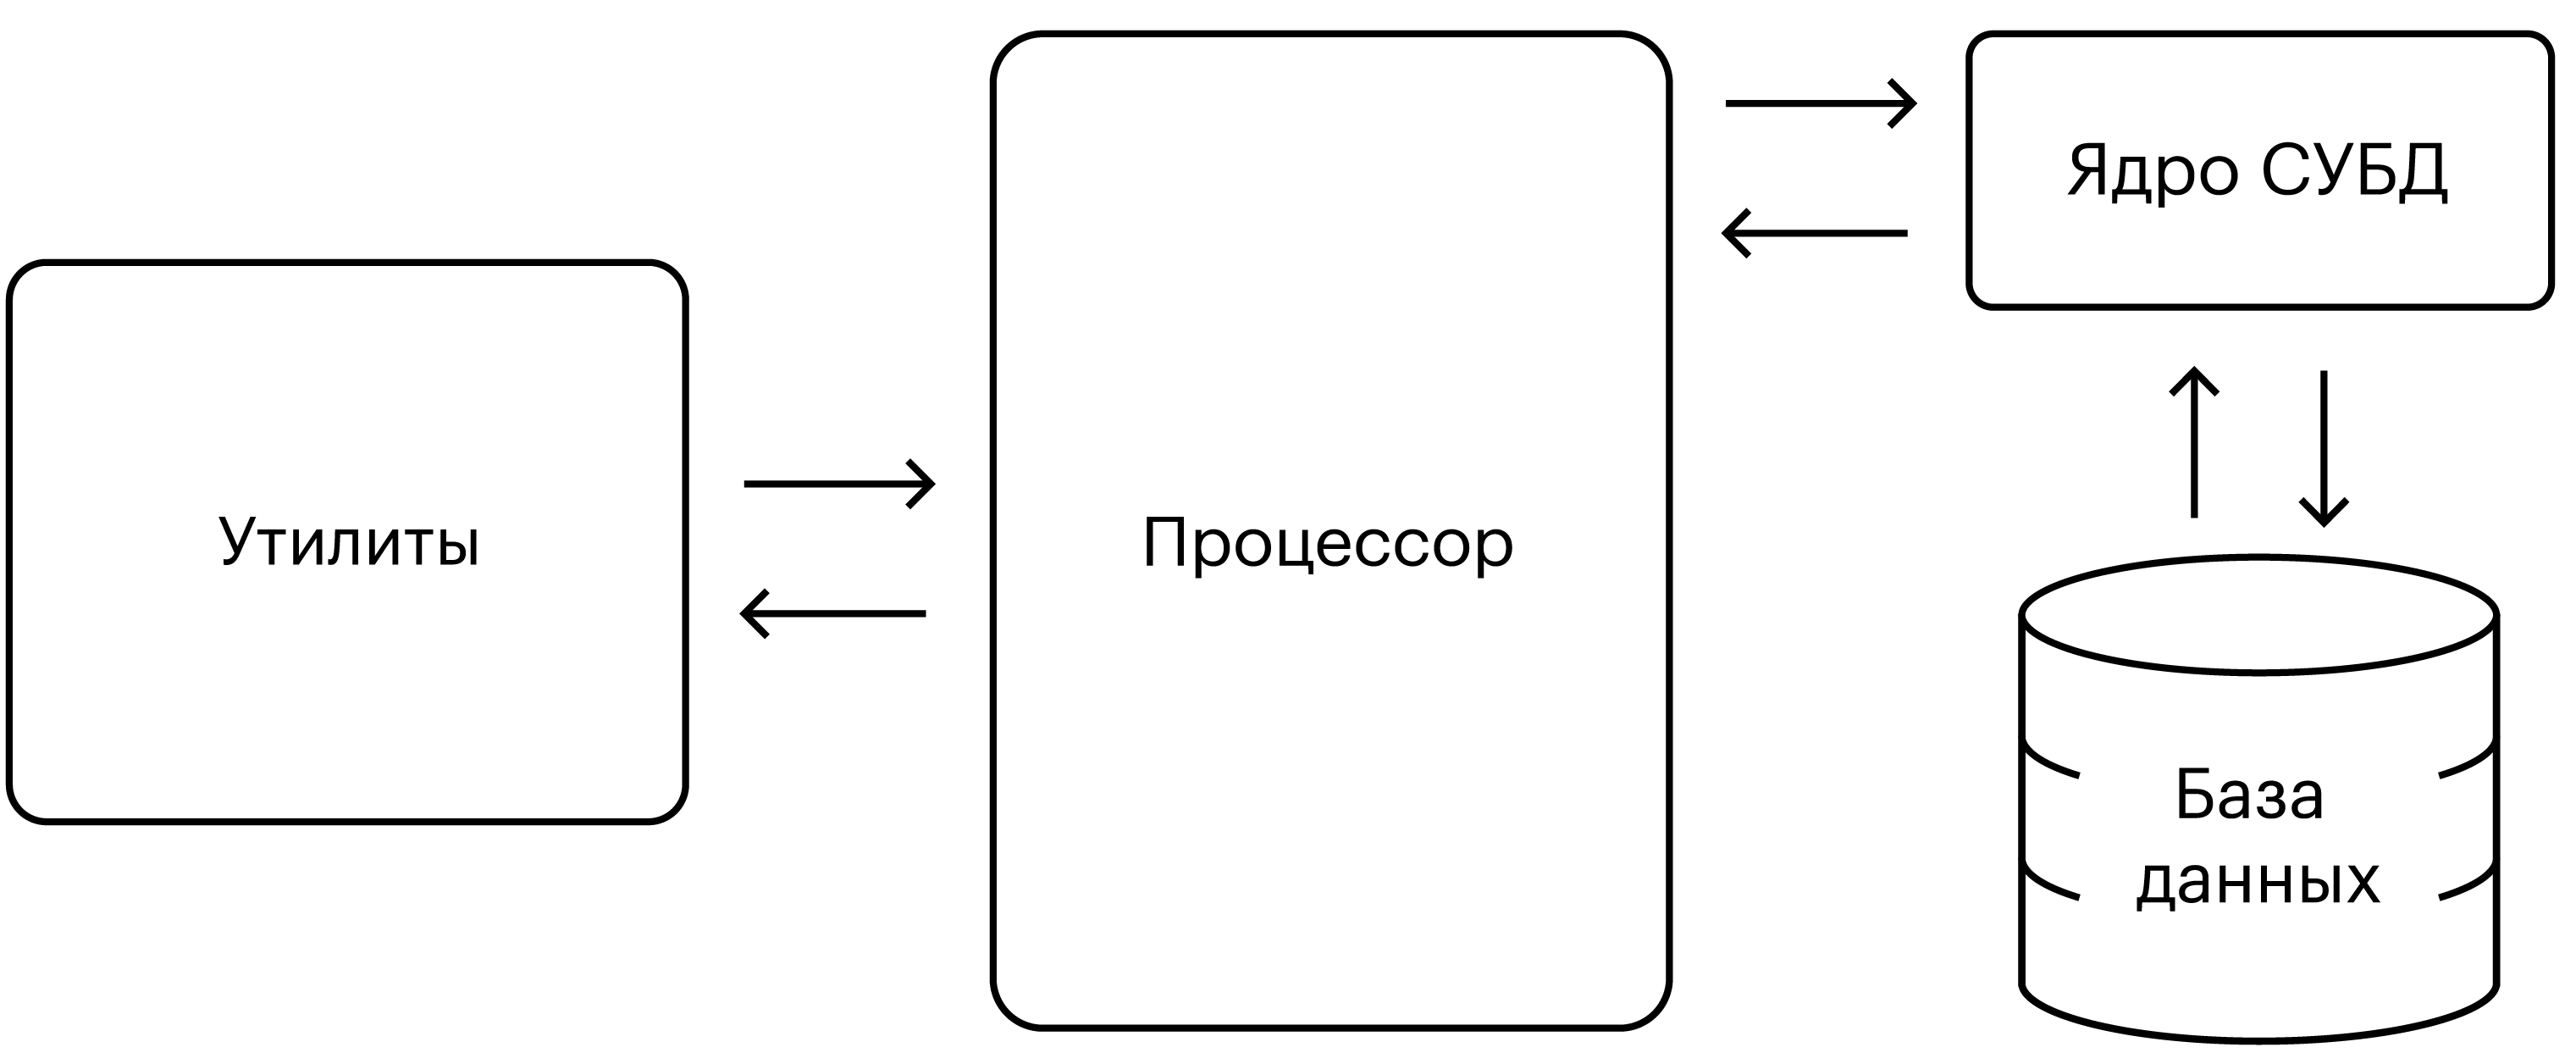 "aspect=1")





**Ядро**. Отвечает за работу всей системы в целом. Через него проходят все процессы обработки данных и их хранения. Ядро следит за всеми изменениями баз данных и фиксирует их.

**Процессор, или компилятор**. Занимается обработкой запросов от пользователей. Главная его задача — преобразовать SQL-запрос в понятные для компьютера команды, а затем вернуть результаты.

**Программные средства, или утилиты**. Нужны, чтобы пользователь мог вводить запросы, а администраторы могли настраивать доступ и другие необходимые параметры.

**Базы данных**. Место, где хранятся данные в упорядоченном, а иногда и в зашифрованном виде. Базы могут различаться по структуре и типам представления данных.

### Задача 5. Выведи компонент СУБД и его роль
После блока про устройство СУБД зафиксируем один из компонентов — процессор запросов. Он принимает SQL и помогает СУБД выполнить его.

Скопируй запрос:

```sql
SELECT 'процессор запросов' AS dbms_component,
       'преобразует SQL в команды' AS component_role;
```

Цель задачи — потренироваться выводить текстовые значения и давать столбцам осмысленные имена.



In [ ]:
%%sql_query cell_5_1
-- Задача 5. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_5_2
--Проверка запроса для задачи 5. Отправь решение на проверку


### Классификация СУБД

Существует несколько классификаций СУБД на основе разных параметров. Мы же рассмотрим следующие:

1. **По расположению баз данных.**

**Локальные**. Содержимое базы данных располагается на одном компьютере — обычно на сервере компании.

**Распределённые**. База данных распределена по разным компьютерам — например, по нескольким серверам.

2.  **По языку запросов.**

**SQL**. Язык структурированных запросов к базам данных. Такие СУБД самые популярные в использовании.

**NoSQL**. Большая группа языков запросов, которые используют отличный от SQL синтаксис и не являются реляционными, например MongoDB, графовые БД и т. д. Эти языки основаны на другом языке программирования, например на Python или JavaScript. СУБД с NoSQL обычно используют там, где реляционные БД оказываются медленными или неэффективными.

3. **По целевому использованию данных.**

**OLAP** (online analytical processing) и **OLTP** (online transaction processing) представляют собой два различных подхода к обработке данных в системах управления базами данных (СУБД). Каждый из них имеет свои особенности, цели и области применения.

Для того чтобы выделить одну из основных особенностей OLTP-систем, необходимо дать определение транзакциям в терминах баз данных.

> **Транзакции** в базах данных представляют собой набор операций, которые выполняются как единое целое, обеспечивая целостность и согласованность данных. Основная цель транзакций — гарантировать, что все изменения, внесённые в базу данных, либо будут применены полностью либо не будут применены вовсе.

| Параметр | **OLTP** | **OLAP** |
|----|----|----|
| Цель | Обработка транзакций в реальном времени | Анализ данных и поддержка принятия решений |
| Структура данных | Нормализованные таблицы | Денормализованные таблицы |
| Тип операций | Вставка, обновление, удаление | Чтение и агрегация |
| Примеры использования | Банковские системы, интернет-магазины | Бизнес-аналитика, отчётность |
| Производительность | Высокая при работе с транзакциями | Высокая при выполнении сложных запросов |

OLTP

Это системы, предназначенные для обработки большого количества операций в реальном времени. Они используются для записи транзакций, таких как покупки, переводы денежных средств, обновление информации по заказу и так далее, и для управления ими. 

**Основные характеристики**

- **Простые запросы**. OLTP-системы прекрасно обрабатывают простые запросы в БД, такие как __вставка__, __обновление__ и __удаление__ __данных__. Более сложные запросы, например агрегацию или соединение таблиц, такие БД выполняют плохо.
- **Высокая скорость и доступность**. Эти системы обеспечивают быструю обработку запросов с минимальной задержкой, что критично для операций, требующих мгновенного ответа, например, при проведении финансовых транзакций.
- **Конкурентный доступ.** OLTP-системы обеспечивают управление конкурентным доступом к данным, предотвращая одновременные изменения одной и той же записи разными пользователями. Это достигается с помощью механизмов блокировок и контроля версий.
- **ACID-свойства**. Это набор свойств, который гарантирует, что:
    - A = Атомарность (Atomicity) — транзакция выполняется полностью или не выполняется вообще.Частичное сохранение изменений запрещено.
    - C = Согласованность (Consistency) — база данных переходит из одного правильного состояния в другое. Все правила и ограничения (например, уникальность полей) строго соблюдаются. То есть результатам запроса можно доверять: именно такие данные именно так хранятся в БД в момент запроса
    - I = Изолированность (Isolation) — параллельные транзакции не мешают друг другу. Результат одновременной работы такой же, как если бы они шли по очереди.
    - D = Долговечность (Durability) — сохранённые данные не пропадут, даже если внезапно отключится питание. Успешная транзакция навсегда записывается в память системы.

**Примеры применения**

OLTP-системы широко используются в различных отраслях:

- **Финансовые услуги** — онлайн-банкинг, банкоматы и системы обработки платежей.
- **Электронная коммерция** — интернет-магазины и платформы для бронирования.
- **Управление запасами** — системы учёта на складах и в магазинах.

**OLAP**

Это системы, специально разработанные для выполнения сложных аналитических запросов и многомерного анализа больших объёмов данных. Они обеспечивают высокую производительность при выполнении запросов на чтение.

**Основные характеристики**

- **Аналитическая обработка**. OLAP позволяет выполнять сложные запросы для анализа больших объёмов исторических данных. Это полезно для бизнес-аналитики и принятия стратегических решений.
- **Низкая частота обновлений**. В отличие от OLTP, данные в OLAP-системах обновляются реже. Основное внимание уделяется анализу и отчётности на основе уже собранных данных.
- **Оптимизация под чтение**. OLAP-системы оптимизированы для чтения данных и могут обрабатывать сложные запросы на анализ с использованием различных методов агрегации.

**Примеры применения**

OLAP-системы находят широкое применение в различных областях.

- **Бизнес-аналитика** — поддержка принятия решений на основе анализа исторических данных.
- **Финансовая отчётность** — позволяет компаниям быстро генерировать отчёты о доходах, расходах и других финансовых показателях.
- **Прогнозирование продаж** — анализ тенденций для прогнозирования будущих продаж на основе исторических данных.
- **Планирование бюджета** — помогает организациям в составлении бюджетов на основе анализа прошлых расходов и доходов.


### Задача 6. Сравни OLTP и OLAP одной строкой
OLTP и OLAP отличаются назначением. В этой мини-задаче нужно вывести различие прямо в строке результата.

Готовый шаблон:

```sql
SELECT 'OLTP' AS transactional_system,
       'частые записи' AS oltp_focus,
       'OLAP' AS analytical_system,
       'анализ и отчёты' AS olap_focus;
```

Такой запрос полезен для тренировки алиасов и строковых литералов.



In [ ]:
%%sql_query cell_6_1
-- Задача 6. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_6_2
--Проверка запроса для задачи 6. Отправь решение на проверку


4. **По используемой модели данных**

> **Модель данных** — это способ организации и представления данных в базе данных, который определяет, как данные хранятся, структурируются и обрабатываются.

Выделяют несколько основных моделей данных.

1. **Иерархическая модель**

Читать подробнее

Это структура, организующая данные в виде древовидной схемы, где каждый элемент (узел) связан с одним родительским элементом и может иметь несколько дочерних элементов. Эта модель была одной из первых в области управления базами данных и до сих пор используется в различных системах.

Примером может служить хорошо известная нам файловая система и структура папок:

/ <br>
├── bin <br>
├── boot <br>
├── etc <br>
├── home <br>
│   └── bob <br>
└── var <br>
    ├── log <br>
        └── www <br>

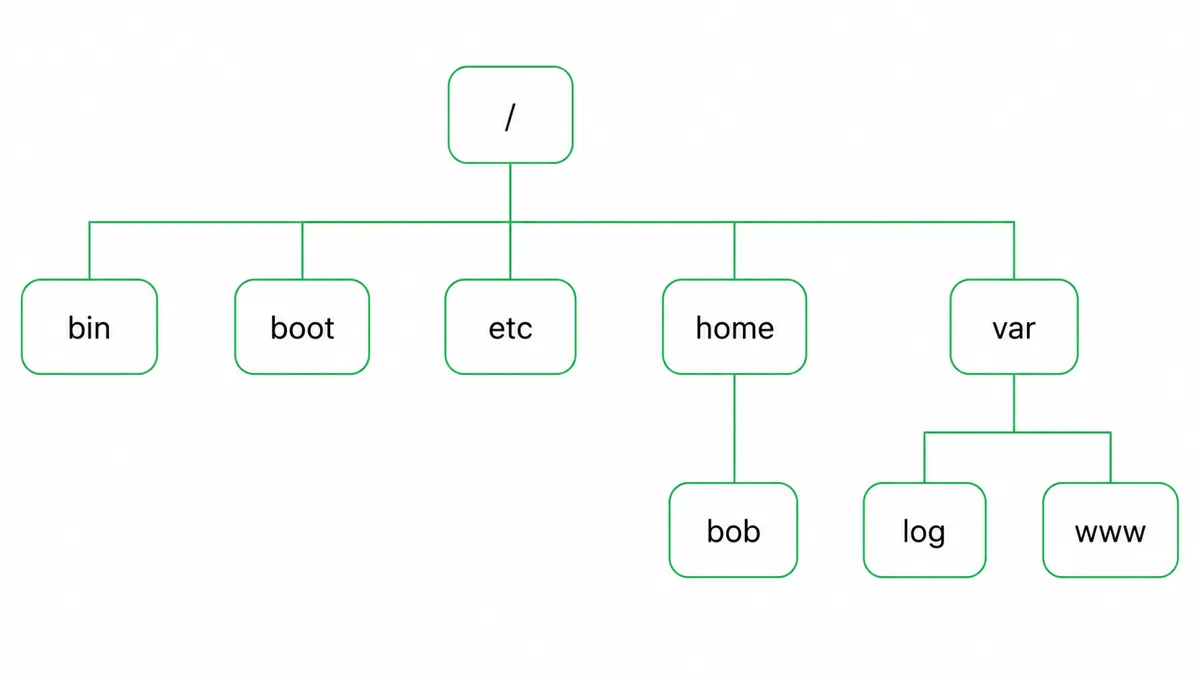



**Преимущества**

- **Простота концепции**. Иерархическая модель интуитивно понятна и легко воспринимается пользователями, что облегчает её реализацию и использование.
- **Эффективное использование памяти**. Модель позволяет эффективно использовать ресурсы системы, особенно при работе с большими объёмами данных.
- **Высокая скорость обработки**. Операции над данными выполняются быстро благодаря простой структуре и чётким связям между узлами.


**Ограничения**

- **Ограниченная гибкость**. Из-за жёсткой структуры изменения в иерархии могут быть сложными. Например, перемещение узла в другую часть дерева требует значительных усилий.
- **Сложность обработки**. При необходимости выполнения сложных запросов или анализа данных возникают трудности из-за навигационного характера доступа к данным.


**Примеры использования**

- **Структура каталогов на жёстком диске**. Файлы организованы в папки, которые могут содержать другие папки.
- **Системный регистр Windows**. Хранит настройки системы в виде иерархии ключей и значений.
- **Организационные структуры**. Моделирование отношений между сотрудниками и отделами компании.

2. **Сетевая модель**

Читать подробнее

Это структура, которая организует данные в виде сетевых отношений, позволяя делать более сложные, по сравнению с иерархической моделью, связи между записями. Данные организованы в виде графа, где узлы представляют записи, а рёбра — связи между ними. Каждая запись может иметь несколько родительских и дочерних записей.



 ![](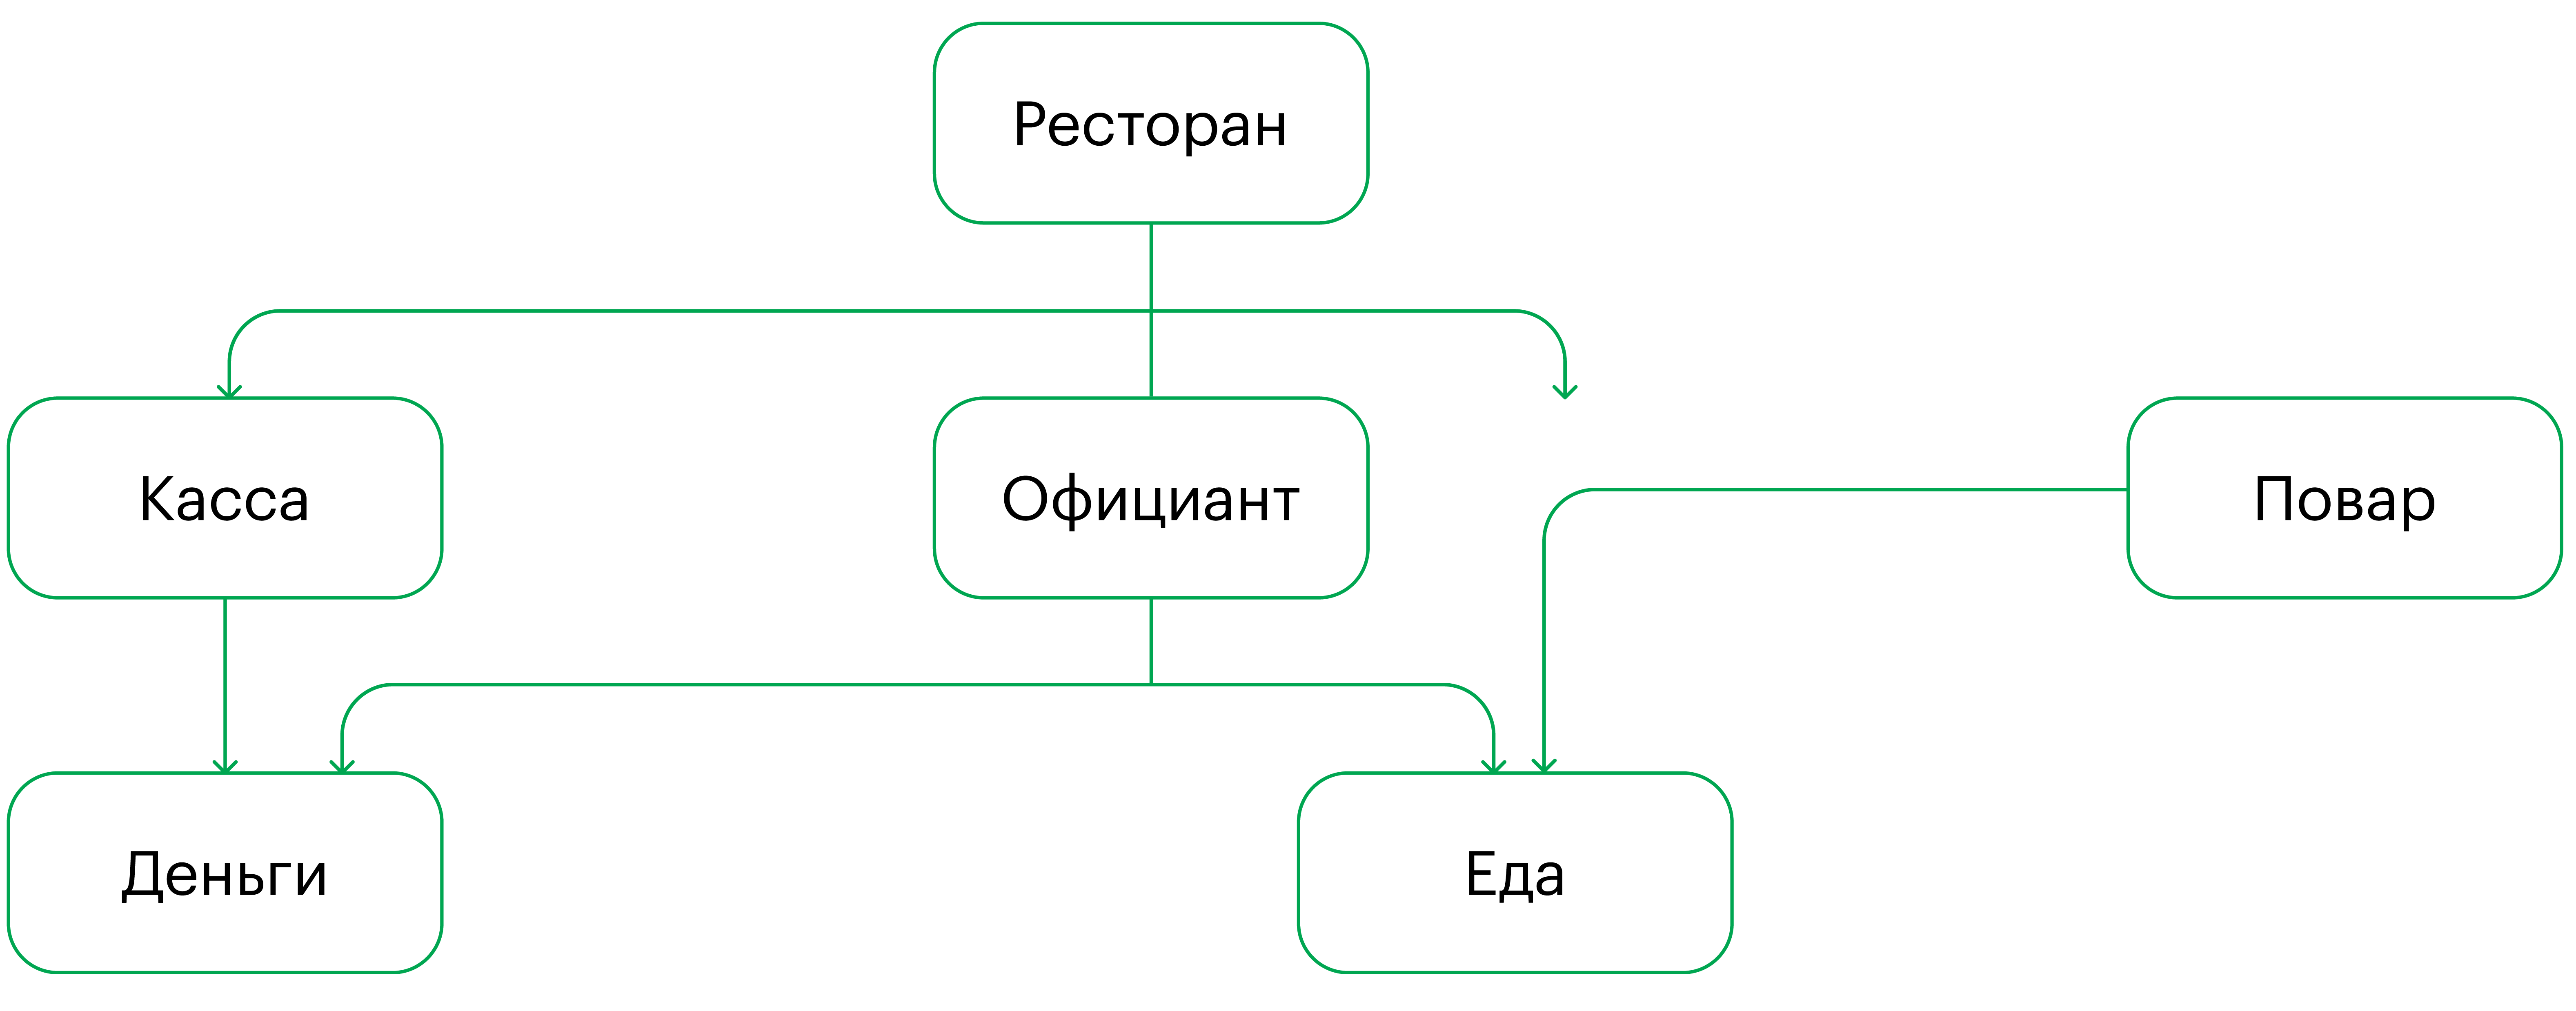 "aspect=1")




**Преимущества**

- **Гибкость в моделировании**. Возможность создания сложных структур данных и отношений между ними делает сетевую модель подходящей для многих приложений, где данные имеют взаимосвязи.
- **Эффективность**. Высокая скорость доступа к данным благодаря прямым указателям и возможности быстрого перемещения по структуре.


**Ограничения**

- **Сложность**. Сложная структура может затруднять понимание и управление данными, особенно для пользователей без технического образования.
- **Зависимость от структуры**. Изменение структуры данных может потребовать значительных изменений в приложениях, использующих эти данные, что делает систему менее гибкой по сравнению с реляционными моделями.

Эта модель была популярна в 1960–1980-х годах. Сейчас классическая сетевая модель устарела, её принципы нашли применение в **графовых базах данных**, которые мы рассмотрим ниже.


3. **Объектно-ориентированная модель**

Читать подробнее

Это подход к организации данных и управлению ими, который основывается на принципах объектно-ориентированного программирования (ООП). Объект имеет набор свойств, называемых атрибутами, и может включать в себя также процедуры для обработки данных, которые называют методами.



 ![](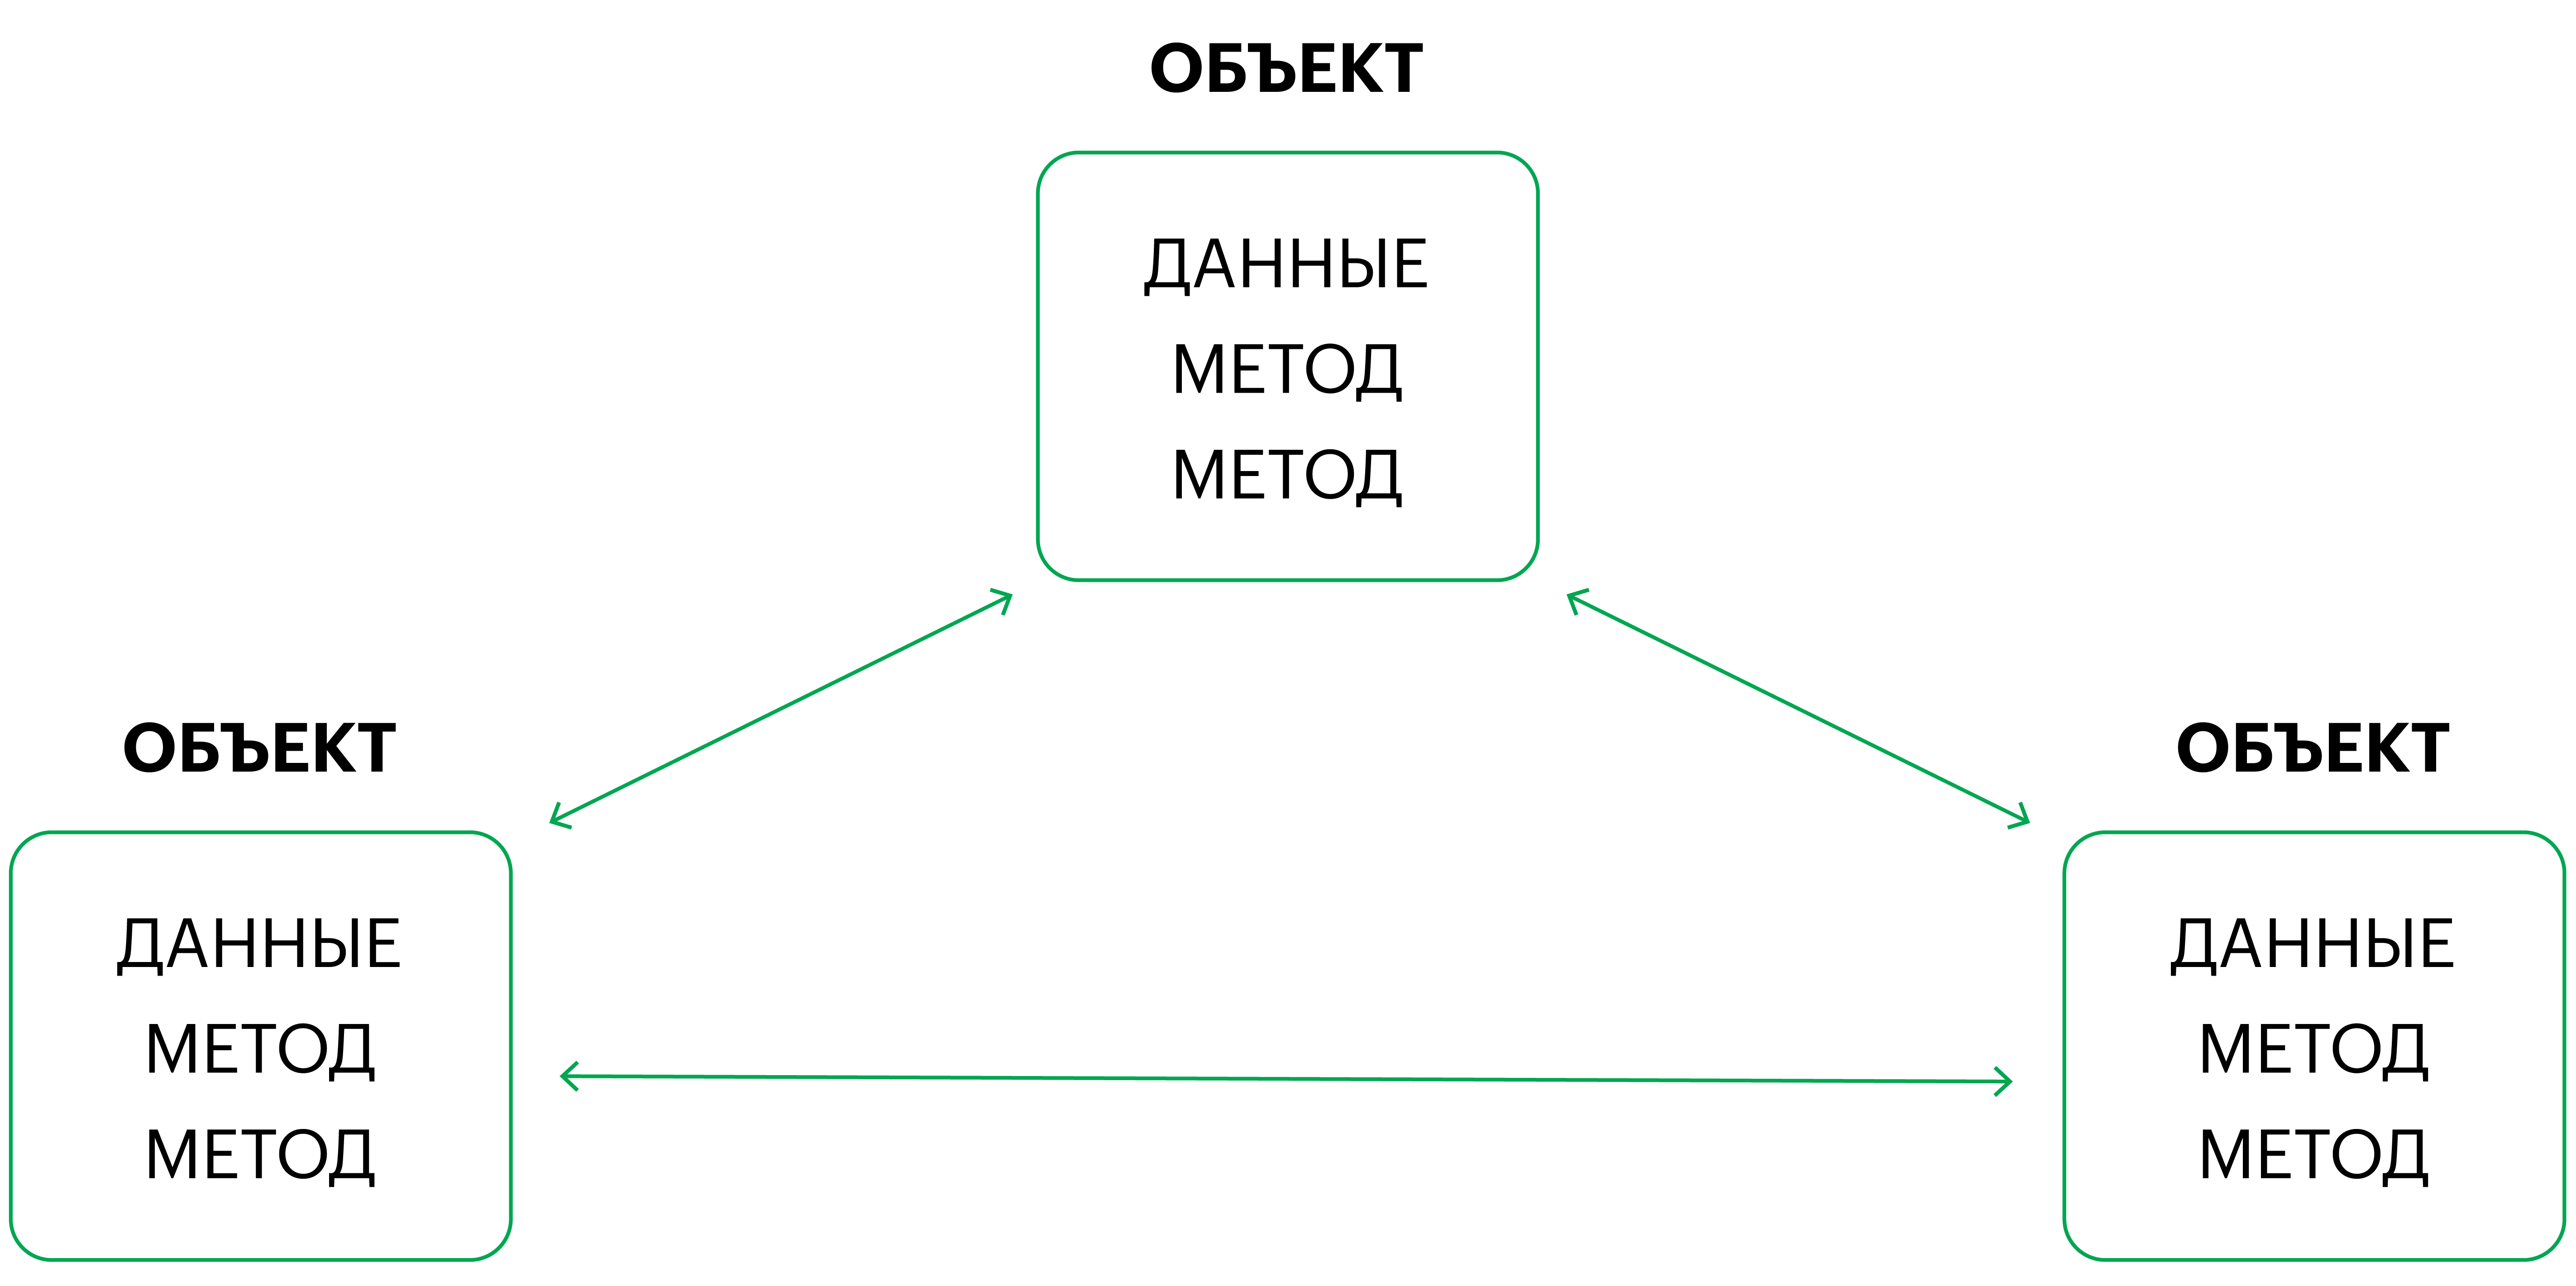 "aspect=1")





**Преимущества**

- **Гибкость**. Объектная модель позволяет легко моделировать сложные взаимосвязи между данными благодаря возможности вложения объектов друг в друга и установления многоуровневых отношений.
- **Повторное использование кода**. Объекты и классы можно многократно использовать в различных приложениях, что снижает затраты на разработку и упрощает поддержку программного обеспечения.
- **Поддержка мультимедийных данных**. Может работать с различными типами данных, включая текстовые, графические и аудио- или видеофайлы.


**Ограничения**

- **Нет стандартизированного языка запросов**. Используются специализированные API.
- **Непопулярность**. Объектные базы данных менее распространены, чем реляционные, из-за исторических причин и ограничений совместимости.
- **Плохая масштабируемость**. Масштабировать объектные базы сложнее из-за сложной структуры данных.


**Примеры использования**

- **1С:Предприятие**. Объектами являются такие сущности, как «Клиент», «Заказ», «Товар». Каждый объект имеет свои атрибуты и методы.

  

4. **Модель «ключ — значение»**

Читать подробнее

Одна из самых простых и широко используемых моделей в базах данных NoSQL. Она основывается на концепции хранения данных в виде пар «ключ — значение», где каждый ключ уникален и служит для идентификации соответствующего значения. Эта модель особенно эффективна для приложений, требующих быстрого доступа к данным.



 ![](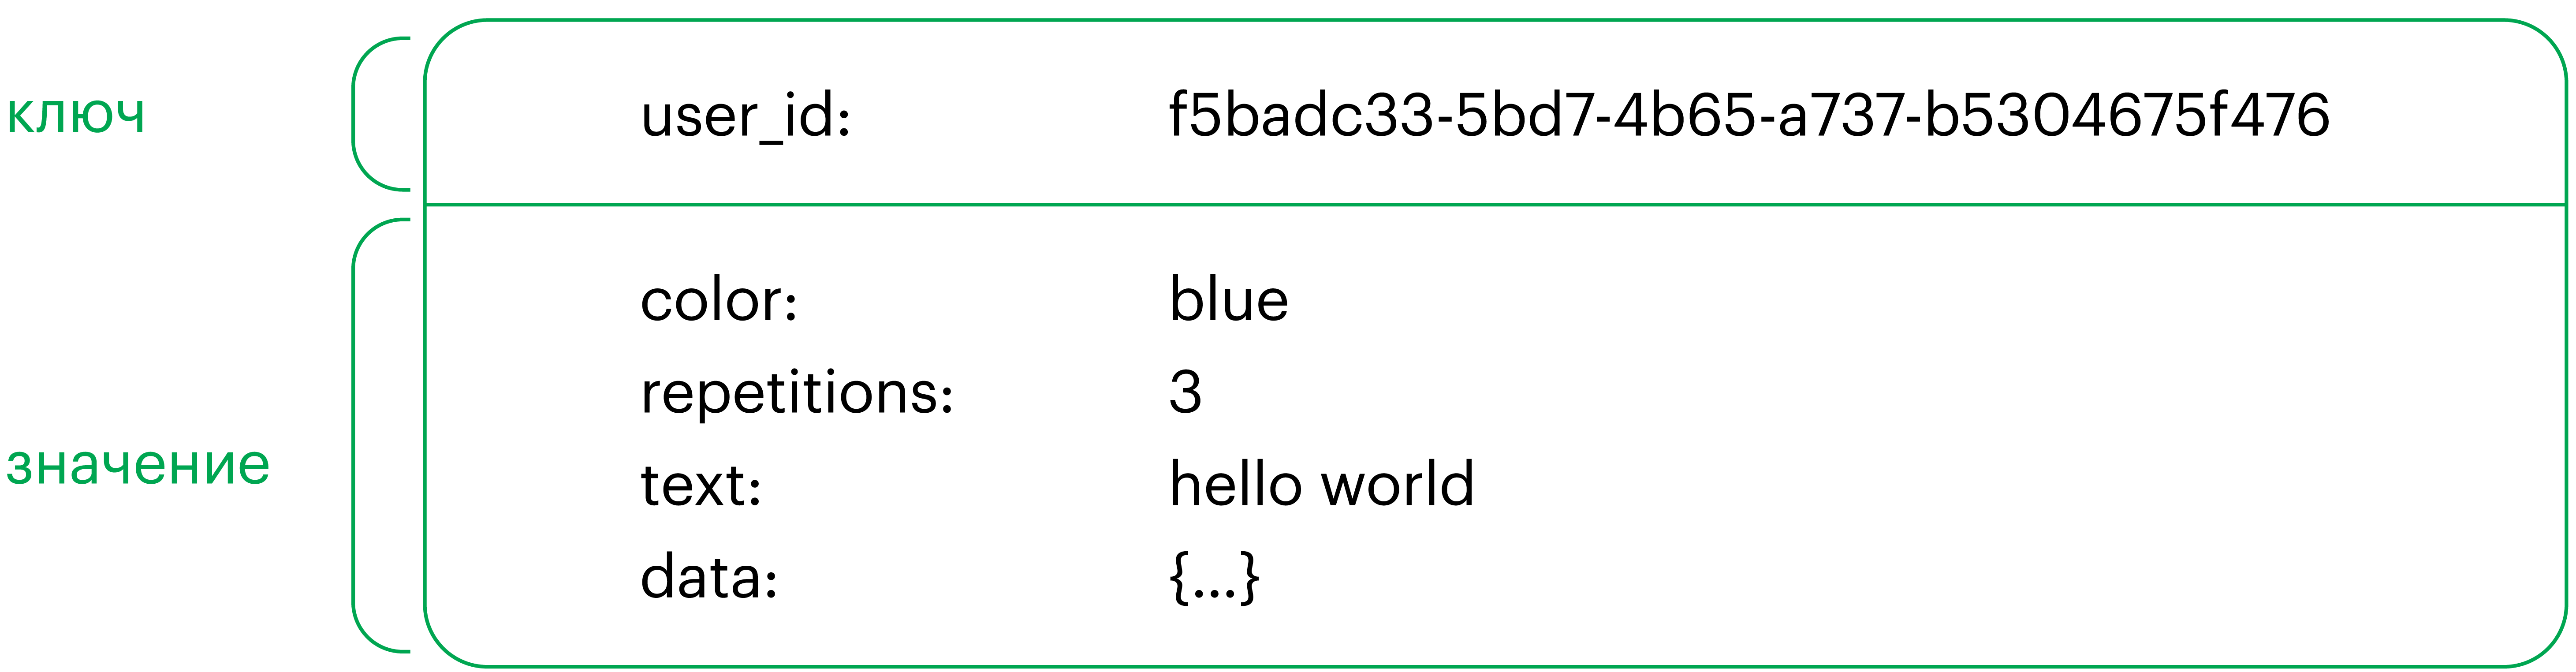 "aspect=1")




- **Ключ:** 

  ```javascript
  "user:1234"
  ```


- **Значение:** 

  ```javascript
  {"name": "Иван", "age": 30, "email": "ivan@example.com"}
  ```


**Преимущества**

- **Высокая производительность**. Быстрый доступ к данным делает эту модель идеальной для кеширования и быстрого поиска.
- **Гибкость**. Значения могут быть различных типов (строки, числа, JSON, бинарные данные), что позволяет хранить разнообразные данные.
- **Простота использования**. Простая структура упрощает разработку и обслуживание приложений.


**Ограничения**

- **Отсутствие сложных запросов**. Базы данных «Ключ — значение» не поддерживают сложные запросы, такие как объединения или фильтрация, что может усложнить обработку данных.
- **Неэффективность при работе с группами записей**. При необходимости извлечения нескольких записей по критериям это может быть менее эффективно по сравнению с реляционными моделями.
- **Отсутствие языка запросов**. Логика обработки данных часто переносится в код приложения, что может усложнить поддержку.


**Примеры использования**

- **Кеширование**. Базы данных «Ключ — значение» часто используются для кеширования данных, таких как результаты запросов или временные данные.
- **Сессии пользователей**. Хранение информации о сессиях пользователей в веб-приложениях.
- **Электронная коммерция.** Хранение информации о товарах, корзинах покупок и заказах.


5. **Графовая модель**

Читать подробнее

Это способ организации и хранения информации в виде графа, где данные представлены в виде узлов (вершин) и рёбер (связей) между ними. Эта модель позволяет эффективно моделировать сложные взаимосвязи между данными, что делает её особенно полезной в сценариях, где важны отношения между объектами.



 ![]( "aspect=1")





Пример графа, представляющего социальную сеть:

```javascript
(Вершины)
Пользователь (ID: 1, Имя: "Анна")
Пользователь (ID: 2, Имя: "Иван")
Город (ID: 3, Название: "Москва")

(Рёбра)
Дружба (Пользователь 1 -> Пользователь 2)
Проживание (Пользователь 1 -> Город 3)
```


**Основные элементы графовой модели**

1. **Узлы** (nodes). Представляют собой сущности или объекты данных. Например, в социальной сети узлом может быть пользователь, а в системе управления запасами — товар.
2. **Рёбра** (edges). Отображают взаимосвязи между узлами. Они могут быть направленными или ненаправленными и содержать свойства, описывающие характер связи. Например, рёбра могут указывать на дружбу между пользователями или связь между товаром и его категорией.
3. **Свойства** (properties). Узлы и рёбра могут иметь дополнительные атрибуты, которые хранят информацию о них. Например, узел пользователя может иметь свойства, такие как имя и возраст, а ребро дружбы — дату установления связи.
4. **Метки** (labels). Метки позволяют классифицировать узлы и рёбра на основе их типа или назначения. Например, вершины могут быть помечены как «пользователь», «город» или «продукт», а рёбра — как «дружит с», «живёт в» и так далее.


**Преимущества**

- **Моделирование сложных отношений**. Графовые базы данных идеально подходят для моделирования данных, где отношения между сущностями играют важную роль. Например, они могут использоваться для анализа социальных сетей, рекомендательных систем и семантических сетей.
- **Гибкий и интуитивный запросы**. Графовые базы данных предоставляют интуитивные средства запросов, которые позволяют легко находить и анализировать данные в графе. Языки запросов, такие как Cypher, спроектированы специально для работы с графами.
- **Высокая производительность для определённых задач**. В задачах, где необходимо находить связи между вершинами, графовые базы данных могут обеспечивать высокую производительность и эффективность.


**Ограничения**

- **Неэффективность для определённых запросов**. Графовые базы данных могут оказаться неэффективными для запросов, которые не связаны с анализом отношений между сущностями.
- **Сложность моделирования данных**. В случае когда структура данных не имеет выраженных отношений, использование графовой модели может быть излишним и усложнить разработку и обслуживание приложения.
- **Сложность масштабирования**. Масштабирование графовых баз данных может оказаться сложной задачей, особенно в случае с большими и высоконагруженными графами.


**Примеры использования**

- **Социальные сети**. Моделирование пользователей и их отношений (друзья, подписчики).
- **Рекомендательные системы**. Предложение товаров или контента на основе анализа связей между пользователями и продуктами.
- **Обнаружение мошенничества**. Анализ транзакций для выявления подозрительных паттернов.

6. **Документоориентированная модель**

Читать подробнее

Это подход к организации и хранению данных, при котором информация сохраняется в виде документов. Эти документы могут иметь разнообразную структуру и содержать вложенные данные, что делает модель гибкой и подходящей для работы с полуструктурированными данными. Документные базы данных обычно используют форматы, такие как JSON (JavaScript Object Notation) или BSON (Binary JSON).



 ![]( "aspect=1")





**Основные характеристики**

1. **Документы**. Основная единица хранения данных — документ. Каждый документ представляет собой набор пар «Ключ — значение» и может содержать вложенные объекты и массивы. Это позволяет хранить сложные структуры данных.
2. **Гибкая схема**. В отличие от реляционных баз данных, где структура данных строго определена, в документоориентированных базах данные могут иметь разные структуры в одной и той же коллекции. Это позволяет легко изменять и обновлять данные без необходимости изменения всей схемы.
3. **Уникальные идентификаторы**. Каждый документ имеет уникальный идентификатор, который обеспечивает быстрый доступ к данным.
4. **Коллекции**. Документы группируются в коллекции, которые можно рассматривать как аналог таблиц в реляционных базах данных. Коллекции могут содержать документы с различной структурой.


**Преимущества**

- **Гибкость**. Схема данных является гибкой, что позволяет хранить и изменять данные без необходимости изменения всей схемы. Это особенно полезно в ситуациях, когда структура данных меняется с течением времени.
- **Мощные запросы**. Документоориентированные базы данных предоставляют мощные инструменты для запросов данных, включая возможность индексации, фильтрации и агрегации данных.
- **Скорость доступа**. Документы могут быть быстро извлечены по уникальному идентификатору, что обеспечивает высокую производительность.
- **Подходит для больших объёмов данных**. Многие документоориентированные базы данных могут масштабироваться для обработки больших объёмов данных и высоких нагрузок.


**Ограничения**

- **Сложность запросов между документами**. В сценариях, где требуется выполнение сложных запросов, связанных с данными из нескольких документов, документоориентированные базы данных могут оказаться менее удобными.
- **Избыточность данных**. Поскольку данные могут дублироваться в разных документах, есть риск избыточности данных и несоответствия данных в разных документах.
- **Не подходит для связанных данных**. В случае когда требуется работать с данными, имеющими сложные взаимосвязи, такие как транзакции и связи между сущностями, модель документов может потребовать дополнительной обработки.


**Примеры использования**

- **Интернет-магазины**. Позволяет быстро извлекать всю информацию о заказе без необходимости выполнять сложные JOIN-запросы.
- **Блоги, новостные порталы**. Каждая статья хранится как отдельный документ, включая текст, изображения, теги, автора, комментарии и так далее.

7. **Реляционная модель ⭐️**

Читать подробнее

Это подход к организации данных, при котором они представлены в виде таблиц (отношений). Каждая таблица состоит из строк (записей) и столбцов (атрибутов), а данные хранятся в структурированном и взаимосвязанном формате. Эта модель была предложена в 1970 году Эдгаром Коддом в статье «A Relational Model of Data for Large Shared Data Banks» и стала основой для большинства современных баз данных.



 ![]( "aspect=1")





**Основные элементы реляционной модели**

1. **Таблица (Relation, отношение).** Основные структуры хранения данных. Каждая таблица имеет уникальное имя и содержит строки и столбцы.

   Пример таблицы «Сотрудники»:

| ID | Имя | Фамилия | Пол | Дата рождения | ОтделID |
|----|----|----|----|----|----|
| 1 | Сергей | Иванов | М | 08.02.1976 | 1 |
| 2 | Анатолий | Петров | М | 22.06.1998 | 2 |
| 3 | Екатерина | Сидорова | Ж | 15.10.2003 | 1 |

2. **Строки (кортежи)**. Каждая строка в таблице представляет собой отдельный объект или запись.
Пример кортежа:

| 1 | Сергей | Иванов | М | 08.02.1976 | 1 |

3. **Столбцы (атрибуты)**. Каждый столбец содержит данные одного типа и описывает определённый аспект записи, например имя, дату или цену.
Пример столбца:

| Имя | 
|----|
| Сергей | 
| Анатолий | 
| Екатерина |

4. **Первичный ключ (Primary Key PK).** Поле или комбинация полей, которые однозначно идентифицируют строку в таблице. В примере выше поле «ID» является первичным ключом. В нём не допускаются дубли. Первичный ключ может состоять из 1 и более атрибутов.

5. **Внешний ключ (Foreign Key FK).** Поле или набор полей в одной таблице, который указывает на первичный ключ или поле с ограничением уникальности другой таблицы, создавая связь между ними. Стоит отметить, что внешний ключ может ссылаться на ту же самую таблицу.

Пример: таблица с сотрудниками может содержать поле «ОтделID», указывающее на «ОтделID» из таблицы «Отделы».
Поле «ОтделID» в таблице «Сотрудники» ссылается на «ОтделID» в таблице «Отделы».
Сотрудники. «ОтделID» (FK) --> Отделы. «ОтделID» (PK).

Таблица «Отделы»:

| ОтделID | Название отдела |
|----|----|
| 1 | Бухгалтерия |
| 2 | Продажи |

6. **Язык для работы с данными. Обычно это язык SQL (Structured Query Language).** Используется для работы с реляционными базами данных и делится на три части:
   - **DDL (Data Definition Language)** — создание и изменение структуры;
   - **DML (Data Manipulation Language)** — управление данными;
     - Отдельно выделяют язык запросов — **DQL (Data Query Language)**.
   - **DCL (Data Control Language)** — управление доступом к данным.
   - **TCL (Transaction Control Language)** — управление транзакциями (и совместной обработкой данных)


**Преимущества**

1. **Структурированность данных.** Данные организованы в чёткой и понятной форме, что упрощает их обработку и анализ.
2. **Целостность данных.** Механизмы ограничения целостности помогают предотвратить ввод некорректных данных и поддерживать согласованность между связанными записями.


3. **Гибкость запросов.** SQL позволяет легко выполнять сложные запросы для извлечения данных и манипуляции ими.
4. **Широкое распространение.** Большинство современных СУБД (MySQL, PostgreSQL, Oracle, SQL Server) основаны на реляционной модели.
5. **Масштабируемость**. Реляционные базы данных могут эффективно обрабатывать большие объёмы данных и обеспечивать высокую производительность.


**Ограничения**

1. **Производительность**. При больших объёмах данных сложные запросы могут выполняться медленно.
2. **Гибкость**. Требует строгой схемы данных, что затрудняет работу с неструктурированными данными.


А теперь давай познакомимся с типами данных, которые применяются в SQL.

### Задача 7. Собери одну строку как пример записи таблицы
В реляционной модели таблица состоит из строк и столбцов. Пока не создаём таблицу, а просто выводим одну строку, похожую на запись из таблицы «Сотрудники».

Выполни:

```sql
SELECT 1 AS employee_id,
       'Сергей' AS first_name,
       'Иванов' AS last_name,
       DATE '1976-02-08' AS birth_date,
       1 AS department_id;
```

Обрати внимание на `DATE '1976-02-08'`: так можно явно записать дату в PostgreSQL.



In [ ]:
%%sql_query cell_7_1
-- Задача 7. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_7_2
--Проверка запроса для задачи 7. Отправь решение на проверку


## **Типы данных**

### **Числовые типы**

Числовые типы включают двух-, четырёх- и восьмибайтные целые, четырёх- и восьмибайтные числа с плавающей точкой, а также десятичные числа с задаваемой точностью.

| Имя | Размер | Описание | Диапазон |
|----|----|----|----|
| smallint | 2 байта | Целое в небольшом диапазоне | −32768… +32767 |
| integer | 4 байта | Типичный выбор для целых чисел | −2147483648… +2147483647 |
| bigint | 8 байт | Целое в большом диапазоне | −9223372036854775808… 9223372036854775807 |
| numeric, decimal | Переменный | Вещественное число с указанной точностью | До 131 072 цифр до десятичной точки и до 16 383 — после |
| float4, real | 4 байта | Вещественное число с переменной точностью | Точность в пределах 6 десятичных цифр |
| float8, double precision | 8 байт | Вещественное число с переменной точностью | Точность в пределах 15 десятичных цифр |
| smallserial | 2 байта | Небольшое целое с автоувеличением | 1… 32767 |
| serial | 4 байта | Целое с автоувеличением | 1… 2147483647 |
| bigserial | 8 байт | Большое целое с автоувеличением | 1… 9223372036854775807 |

Подробная информация о числовых типах данных

**Целочисленные типы**

Типы `smallint`, `integer` и `bigint` хранят целые числа, то есть числа без дробной части, имеющие разные допустимые диапазоны. Попытка сохранить значение, выходящее за рамки диапазона, приведёт к ошибке.

Чаще всего используется тип `integer`, это наиболее сбалансированный выбор ширины диапазона, размера и быстродействия. Тип `smallint` обычно применяется, только когда крайне важно уменьшить размер данных на диске. Тип `bigint` предназначен для тех случаев, когда числа не умещаются в диапазон типа `integer`.

В SQL определены только типы `integer` (или int), `smallint` и `bigint`. Имена типов int2, int4 и int8 выходят за рамки стандарта PostgreSQL, хотя могут работать и в некоторых других СУБД.


**Числа с фиксированной точностью**

Тип `numeric` позволяет хранить числа с очень большим количеством цифр. Он рекомендуется для хранения денежных сумм и других величин, где важна точность. Вычисления с типом `numeric` дают точные результаты в случаях, когда это возможно, — например, при сложении, вычитании и умножении. Однако операции со значениями `numeric` выполняются гораздо медленнее, чем с целыми числами или типами с плавающей точкой.

```sql
NUMERIC(точность, масштаб)
```

*Масштаб* значения `numeric` определяет количество десятичных цифр в дробной части, справа от десятичной точки, а *точность* — общее количество значимых цифр в числе, то есть количество цифр по обе стороны от десятичной точки. Например, число 23,5141 имеет точность 6 и масштаб 4. Целочисленные значения можно считать числами с масштабом 0.

Типы `decimal` и `numeric` равнозначны.


**Типы с плавающей точкой**

Тип данных с плавающей точкой в PostgreSQL используется для хранения чисел с дробной частью (то есть вещественных чисел), которые могут иметь различную степень точности. Этот тип данных применим, если необходимо представлять числа с высокой степенью детализации или для вычислений, где результатом могут быть дробные значения.

Если требуется высокая точность (например, для денежных операций), лучше использовать тип `numeric` или `decimal`, так как они хранят числа с фиксированной запятой.

Типы данных `real` и `double precision` хранят приближённые числовые значения с переменной точностью.

PostgreSQL также поддерживает форматы `float` и `float(p)`, оговорённые в стандарте SQL, для указания неточных числовых типов. Здесь ***p*** определяет минимально допустимую точность в ***двоичных*** цифрах. PostgreSQL воспринимает запись от `float(1)` до `float(24)` как выбор типа `real`, а запись от `float(25)` до `float(53)` — как выбор типа `double precision`. Значения ***p*** вне допустимого диапазона вызывают ошибку. Если `float` указывается без точности, подразумевается тип `double precision`.


**Столбцы с автоматическим увеличением**

Типы данных `smallserial`, `serial` и `bigserial` не являются настоящими типами, а представляют собой просто удобное средство для создания столбцов с уникальными числами.

Имена типов `serial` и `serial4` равнозначны: они создают столбцы `integer`. Являются синонимами и имена `bigserial` и `serial8`, но они создают столбцы `bigint`.



### Задача 8. Выведи числа разных типов
После числовых типов полезно увидеть, как значения можно явно привести к типам. Здесь будут целое число, точная сумма и приблизительное число с плавающей точкой.

Скопируй запрос:

```sql
SELECT 42::integer AS orders_count,
       1990.50::numeric(8,2) AS order_amount,
       0.15::double precision AS discount_rate;
```

Оператор `::` в PostgreSQL означает «привести значение к типу».



In [ ]:
%%sql_query cell_8_1
-- Задача 8. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_8_2
--Проверка запроса для задачи 8. Отправь решение на проверку


### Задача 9. Сравни numeric и double precision
`numeric` используют там, где важна точность, а `double precision` — для приблизительных вещественных вычислений. Здесь результат простой, но синтаксис важен.

Выполни:

```sql
SELECT 10::numeric / 4 AS numeric_result,
       10::double precision / 4 AS float_result;
```

Оба выражения считаются без `FROM`, потому что данные берутся прямо из самого запроса.



In [ ]:
%%sql_query cell_9_1
-- Задача 9. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_9_2
--Проверка запроса для задачи 9. Отправь решение на проверку


**Строковые типы**

| Имя | Описание |
|----|----|
|character varying(n), varchar(n)| Строка ограниченной переменной длины |
|character(n), char(n), bpchar(n)| Строка фиксированной длины, дополненная пробелами |
|text| Строка неограниченной переменной длины |

**Подробнее о символьных типах данных**

SQL определяет два основных символьных типа: `character varying(n)` и `character(n)`, где ***n*** — положительное число. Оба этих типа могут хранить текстовые строки длиной до ***n*** символов (не байтов). 

Если длина сохраняемой строки оказывается меньше объявленной, значения типа `character` будут дополняться пробелами, а тип `character varying` просто сохранит короткую строку.

Помимо этого, в PostgreSQL есть тип `text`, в котором можно хранить строки произвольной длины. Хотя тип `text` не описан в стандарте SQL, его поддерживают и некоторые другие СУБД SQL. Тип `text` — это встроенный строковый тип данных PostgreSQL, и большинство встроенных функций, работающих со строками, объявляются принимающими или возвращающими `text`, а не `character varying`.

Имя типа `varchar` является псевдонимом для `character varying`, а `char` и `bpchar` (с указанием длины) — для `character`. Псевдонимы `varchar` и `char` определены в стандарте SQL, но `bpchar` — это расширение PostgreSQL.

Если ***n*** задано, оно должно быть больше нуля и меньше или равно 10485760. При использовании типов `character varying` (или `varchar`) без указания длины принимаются строки любой длины. При использовании типа `bpchar` без указания длины также принимаются строки любой длины, но конечные пробелы семантически не учитываются. Записи `character` (или `char`) без указания длины соответствует `character(1)`.

Для хранения короткой строки (до 126 байт) требуется дополнительно 1 байт плюс размер самой строки, включая дополняющие пробелы для типа `character`. Для строк длиннее требуется не 1, а 4 дополнительных байта. СУБД может автоматически сжимать длинные строки, так что физический размер на диске может быть меньше. Очень длинные текстовые строки переносятся в отдельные структуры, чтобы они не замедляли работу с другими столбцами. В любом случае максимально возможный размер строки составляет около 1 ГБ. (Допустимое значение ***n*** в объявлении типа данных меньше этого числа. Это объясняется тем, что, в зависимости от кодировки, каждый символ может занимать несколько байтов. Если ты хочешь сохранять строки без определённого предела длины, используй типы `text` или `character varying` без указания длины, а не задавай какое-либо большое максимальное значение.


### Задача 10. Поработай со строкой и функцией length
Строковые типы хранят текст. В этой задаче ты выведешь строку и применишь две простые функции: `LENGTH` считает длину строки, `UPPER` переводит текст в верхний регистр.

Почти всё решение уже здесь:

```sql
SELECT 'PostgreSQL'::text AS dbms_name,
       LENGTH('PostgreSQL') AS name_length,
       UPPER('sql') AS upper_sql;
```

Это хороший первый пример функций в `SELECT`.



In [ ]:
%%sql_query cell_10_1
-- Задача 10. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_10_2
--Проверка запроса для задачи 10. Отправь решение на проверку


**Типы даты и времени**

| Имя | Размер | Описание | Наименьшее значение | Наибольшее значение | Точность |
|----|----|----|----|----|----|
|timestamp [ (p) ] [ without time zone ]| 8 байт | Дата и время (без часового пояса) | 4713 до н. э. | 294 276 н. э. | 1 микросекунда |
|timestamp [ (p) ] with time zone| 8 байт | Дата и время (с часовым поясом) | 4713 до н. э. | 294 276 н. э. | 1 микросекунда |
|date | 4 байта | Дата (без времени суток) | 4713 до н. э. | 5 874 897 н. э. | 1 день |
| time [ (p) ] [ without time zone ]| 8 байт | Время суток (без даты) | 00:00:00 | 24:00:00 | 1 микросекунда |
|time [ (p) ] with time zone| 12 байт | Время дня (без даты) с часовым поясом | 00:00:00 + 1559 | 24:00:00 − 1559 | 1 микросекунда |
| interval [ поля ] [ (p) ]| 16 байт | Временной интервал | −178 000 000 лет | 178 000 000 лет | 1 микросекунда |

Подробнее о типах даты/времени

Стандарт SQL требует, чтобы тип `timestamp` подразумевал timestamp without time zone (время без часового пояса), и PostgreSQL следует этому. Для краткости timestamp with time zone можно записать как timestamptz — это расширение PostgreSQL.

Типы `time`, `timestamp` и `interval` принимают необязательное значение точности ***p***, определяющее, сколько знаков после точки должно сохраняться в секундах. По умолчанию точность не ограничивается. Допустимые значения ***p*** лежат в диапазоне от 0 до 6.

Предпочтительным форматом является следующий (ISO):

```javascript
1999-01-08 04:05:06
```

Или с указанием смещения часового пояса от UTC:

```javascript
1999-01-08 04:05:06 -8:00
```



### Задача 11. Выведи дату, время и timestamp
В блоке про даты и время важно различать `date`, `time` и `timestamp`. Выведем все три значения в одном запросе.

Скопируй:

```sql
SELECT DATE '1999-01-08' AS sample_date,
       TIME '04:05:06' AS sample_time,
       TIMESTAMP '1999-01-08 04:05:06' AS sample_timestamp;
```

`date` хранит дату, `time` — время суток, `timestamp` — дату и время вместе.



In [ ]:
%%sql_query cell_11_1
-- Задача 11. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_11_2
--Проверка запроса для задачи 11. Отправь решение на проверку


### Задача 12. Прибавь интервал к дате
Интервалы позволяют прибавлять к дате дни, месяцы, часы и другие единицы времени. Функция `DATE_PART` достаёт часть даты, например год.

Выполни:

```sql
SELECT DATE '1999-01-08' + INTERVAL '7 days' AS date_plus_week,
       DATE_PART('year', DATE '1999-01-08') AS date_year;
```

Это всё ещё `SELECT` без `FROM`: таблица для такого вычисления не нужна.



In [ ]:
%%sql_query cell_12_1
-- Задача 12. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_12_2
--Проверка запроса для задачи 12. Отправь решение на проверку


**Логический тип**

В PostgreSQL есть стандартный SQL-тип `boolean`. Тип `boolean` может иметь следующие состояния: «true», «false» и третье состояние, «unknown», которое представляется SQL-значением NULL.

| Имя | Размер | Описание |
|----|----|----|
|boolean| 1 байт | Состояние: истина или ложь. Значения — true, false |

Подробнее о логических типах

Следующие значения соответствуют «true»:

```sql
true
yes
on
1
t
```

А эти значения равны «false»:

```sql
false
no
off
0
f
```


Ключевые слова TRUE и FALSE являются предпочтительными (соответствующими стандарту SQL) для записи логических констант в SQL-запросах.

### Задача 13. Проверь логические значения boolean
Тип `boolean` хранит `true`, `false` или неизвестное значение через `NULL`. Начнём с простого логического выражения.

Используй:

```sql
SELECT TRUE AS is_true_value,
       FALSE AS is_false_value,
       TRUE AND NOT FALSE AS logic_result;
```

`TRUE AND NOT FALSE` вернёт `true`.



In [ ]:
%%sql_query cell_13_1
-- Задача 13. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_13_2
--Проверка запроса для задачи 13. Отправь решение на проверку


### Задача 14. Проверь NULL через IS NULL
`NULL` означает отсутствие известного значения. Его не проверяют через `= NULL`; для этого используют `IS NULL`. А `COALESCE` позволяет подставить значение по умолчанию.

Готовый запрос:

```sql
SELECT NULL::boolean AS unknown_boolean,
       NULL IS NULL AS null_check,
       COALESCE(NULL::text, 'нет данных') AS fallback_text;
```

Это последняя мини-практика по типам данных перед контрольными вопросами.



In [ ]:
%%sql_query cell_14_1
-- Задача 14. Ячейка 1. Тренировка. Соединение postgres 



In [ ]:
%%sql_query_submit cell_14_2
--Проверка запроса для задачи 14. Отправь решение на проверку


## Полезные ссылки и используемые источники

<https://postgrespro.ru/docs/postgresql/17/datatype>

### Вопросы по теме

### Задача 15. Отличи базу данных от СУБД
Что лучше всего описывает роль СУБД?
```text
1. Файл, в котором физически лежат данные
2. Программа, которая позволяет создавать, читать, изменять и защищать данные в базе
3. Только таблица с несколькими строками
4. Любой набор чисел и строк без структуры
```


In [ ]:
# Введи ответ в задании 15
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(15, solution)


### Задача 16. Определи данные
Какой вариант лучше всего подходит под определение данных из лонгрида?
```text
1. Набор фактов, которые нужно хранить и обрабатывать
2. Только SQL-запросы
3. Только картинки и файлы на диске
4. Только таблицы с числовыми столбцами
```


In [ ]:
# Введи ответ в задании 16
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(16, solution)


### Задача 17. Компонент СУБД для обработки SQL
Какой компонент СУБД преобразует SQL-запрос пользователя в команды, понятные системе?
```text
1. Ядро
2. Процессор или компилятор запросов
3. Резервная копия
4. Первичный ключ
```


In [ ]:
# Введи ответ в задании 17
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(17, solution)


### Задача 18. Выбери пример OLTP
Какой сценарий больше похож на OLTP-систему?
```text
1. Построение годового аналитического отчёта по продажам
2. Онлайн-оплата заказа в интернет-магазине
3. Анализ поведения клиентов за пять лет
4. Расчёт агрегированной витрины для BI-дашборда
```


In [ ]:
# Введи ответ в задании 18
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(18, solution)


### Задача 19. Выбери пример OLAP
Какой сценарий больше похож на OLAP-систему?
```text
1. Добавление нового товара в корзину
2. Перевод денег между счетами
3. Анализ продаж по регионам и месяцам
4. Регистрация нового пользователя
```


In [ ]:
# Введи ответ в задании 19
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(19, solution)


### Задача 20. Определи модель «ключ — значение»
Какая структура лучше всего описывает модель «ключ — значение»?
```text
1. Уникальный ключ и связанное с ним значение произвольного типа
2. Строго нормализованные таблицы с внешними ключами
3. Только дерево с одним родителем у каждого узла
4. Только список файлов в папке
```


In [ ]:
# Введи ответ в задании 20
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(20, solution)


### Задача 21. Определи графовую модель
Для какой задачи графовая модель обычно подходит лучше всего?
```text
1. Хранение простого справочника кодов валют
2. Моделирование пользователей социальной сети и связей между ними
3. Хранение одной настройки по одному ключу
4. Запись одной строки отчёта в CSV
```


In [ ]:
# Введи ответ в задании 21
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(21, solution)


### Задача 22. Реляционная модель данных
Как в реляционной модели обычно представляются данные?
```text
1. В виде таблиц, состоящих из строк и столбцов
2. Только в виде вложенных JSON-документов
3. Только в виде вершин и рёбер
4. Только в виде файлов без схемы
```


In [ ]:
# Введи ответ в задании 22
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(22, solution)


### Задача 23. Назначение первичного ключа
Для чего нужен первичный ключ?
```text
1. Чтобы однозначно идентифицировать строку в таблице
2. Чтобы автоматически отсортировать таблицу
3. Чтобы запретить любые изменения таблицы
4. Чтобы заменить SQL-запросы
```


In [ ]:
# Введи ответ в задании 23
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(23, solution)


### Задача 24. Назначение внешнего ключа
Что делает внешний ключ?
```text
1. Связывает столбец одной таблицы с ключом другой таблицы и помогает поддерживать целостность данных
2. Ускоряет любой SELECT-запрос в 100 раз
3. Хранит пароль пользователя
4. Автоматически создаёт новую базу данных
```


In [ ]:
# Введи ответ в задании 24
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(24, solution)


### Задача 25. Группа SQL для создания структуры
К какой группе SQL обычно относят команды создания и изменения структуры таблиц?
```text
1. DDL
2. DML
3. DCL
4. TCL
```


In [ ]:
# Введи ответ в задании 25
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(25, solution)


### Задача 26. Тип для точных денежных расчётов
Какой тип в PostgreSQL лучше выбрать для денежных расчётов, где важна точность?
```text
1. numeric или decimal
2. real
3. float4
4. boolean
```


In [ ]:
# Введи ответ в задании 26
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(26, solution)


### Задача 27. Строка произвольной длины
Какой строковый тип PostgreSQL обычно используют для текста произвольной длины?
```text
1. text
2. boolean
3. smallint
4. interval
```


In [ ]:
# Введи ответ в задании 27
solution = '''
    # Укажи номер варианта ответа 
    '''
runner.run_quiz(27, solution)
